In [1]:
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
#Cas n°1 : Ici l'économie se déroule dans un environnement libre et stable, les agents sont rationnels, l'information est parfaite et il n'y a pas d'impact ni d'influence d'acteurs exterieurs (état etc..)
#il n'y a donc pas non plus de régulation ni d'intervention étatique et ni de bulles speculatives

In [3]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.8
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.2<1:
               vecteur.append(e*1.2)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat, vecteurpopulation):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e < 0.4])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat):
    """fonction qui calcule l'indice global du marché en fonction de l'état du marché et du nombre d'investisseurs"""
    res = 0
    for i in range(len(vecteurindice)):
        res = 0
        if etat == 0:
            for inv in vecteur_investisseurs:
                res = res - np.random.normal(0.000001, 0.00001)          #on simplifie, tous les prix diminuent lors d'une crise
            # print(res)
            vecteurindice[i] += res
    
        if etat == 2:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0.001, 0.00001)
            vecteurindice[i] += res

        if etat == 1:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0, 0.00001)
            vecteurindice[i] += res
        
        if vecteurindice[i] < 0.01:
            vecteurindice[i] = 0.01
    nv_indice = np.mean(vecteurindice) 
    return nv_indice



def probamatrice(matrice,etat, indice1, indice0, epsilon): 
    """fonction qui permet de modifier la probabilité de la matrice de transition en fonction de la variation de l'indice global des prix"""
    variation = (indice1 - indice0)/max(indice0, 0.01) #pour éviter une division par zéro
    sensibilité = epsilon

    if abs(variation) < 0.0001:
        return matrice
    
    if indice1 <0.01:
        matrice[etat][0] = min(0.99, matrice[etat][0] + sensibilité) 
        matrice[etat][2] = max(0, matrice[etat][2] - sensibilité)
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
        return matrice
    
    transfert_max = 0.1  #securtité pour éviter des variations trop brusques de la matrice de transition

    if variation > 0:
        transfert = min(matrice[etat][0], abs(sensibilité*variation))
        transfert = min(transfert, transfert_max)

        matrice[etat][0] -= transfert 
        matrice[etat][2] += transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
    
    elif variation < 0:
        transfert = min(matrice[etat][2], abs(sensibilité*variation))
        transfert = min(transfert, transfert_max)

        matrice[etat][0] += transfert
        matrice[etat][2] -= transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]     

    return matrice


In [4]:

def fonction_cas1(matrice, etat, vecteurpopulation, vecteurindice, n, epsilon):
    nvetat = 0
    vecteur_indices = [1]
    matrice_pop = []
    vecteur_etats = [etat]
    res = 0
    max = -1
    for i in range(n):
        nvetat = passage(matrice, vecteur_etats[i])

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = prop_investisseurs(nvetat, vecteurpopulation)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat)
        vecteur_indices.append(nouvel_indice)
        
        matrice = probamatrice(matrice, nvetat, vecteur_indices[i], vecteur_indices[i+1],epsilon)

        vecteur_etats.append(nvetat)
        
        if nvetat == etat:
            res += 1
        else:
            res = 1 
            
        if res > max:
            max = res

    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop, max

    

In [5]:
#Les 3 cas suivants traitent une société dont le marché est plutot stable, ca veut dire que si on est dans un etat on est sur d'y rester


In [6]:
indice0 = 1
population = 100
titres2 = 10
res = [indice0]
matrice = [[0.999, 0.001 ,0], [0.05,0.9,0.05], [0,0.001,0.999]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation3 = np.random.normal(0.5, 0.15, population) 
vecteurindices3 = np.array([np.random.uniform() for _ in range(titres2)])



In [7]:
etat2 = fonction_cas1(matrice=matrice, etat= 2, vecteurpopulation = vecteurpopulation3, vecteurindice=vecteurindices3, n=20, epsilon =0.01)
etat2[0]

[[0.999, 0.001, 0],
 [0.05, 0.9, 0.05],
 [0.014014838701597565, 0.0010000000000000009, 0.9849851612984024]]

In [8]:
res = [indice0]
matrice = [[0.99, 0.01 ,0], [0.05,0.9,0.05], [0,0.01,0.99]]  #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation2 = np.random.normal(0.5, 0.15, population) 
vecteurindices2 = np.array([np.random.uniform() for _ in range(titres2)])



In [9]:
etat1 = fonction_cas1(matrice=matrice, etat= 1, vecteurpopulation = vecteurpopulation2, vecteurindice=vecteurindices2, n=20, epsilon =0.01)
etat1[0]

[[0.99, 0.01, 0],
 [0.04394821711548024, 0.9, 0.056051782884519764],
 [0.008841190914222615, 0.010000000000000009, 0.9811588090857774]]

In [10]:
res = [indice0]
matrice = [[0.99, 0.01 ,0], [0.05,0.9,0.05], [0,0.01,0.99]]  #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation1 = np.random.normal(0.5, 0.15, population) 
vecteurindices1 = np.array([np.random.uniform() for _ in range(titres2)])
etat0 = fonction_cas1(matrice=matrice, etat= 0, vecteurpopulation = vecteurpopulation1, vecteurindice=vecteurindices1, n=20, epsilon =0.01)

In [11]:
etat0 = fonction_cas1(matrice=matrice, etat= 0, vecteurpopulation = vecteurpopulation1, vecteurindice=vecteurindices1, n=20, epsilon =0.01)
etat0[0]

[[0.9695448753577856, 0.010000000000000168, 0.02045512464221428],
 [0.05, 0.9, 0.05],
 [0, 0.01, 0.99]]

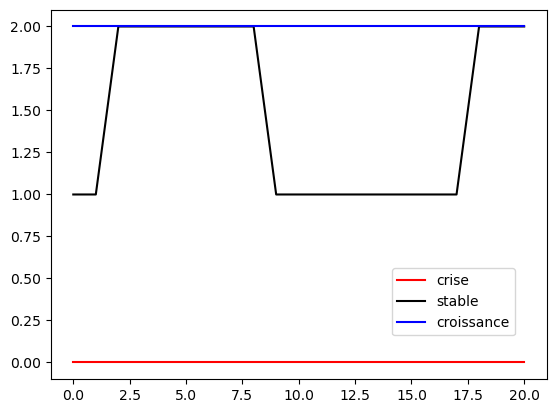

In [12]:
abscisse = np.arange(0, len(etat0[1]), 1)
plt.plot(abscisse, etat0[1], color = 'red', label = "crise")
plt.plot(abscisse, etat1[1], c ='black', label = "stable")
plt.plot(abscisse, etat2[1], c ='blue', label = "croissance")
plt.legend(loc = "lower right", bbox_to_anchor=(0.95, 0.1))


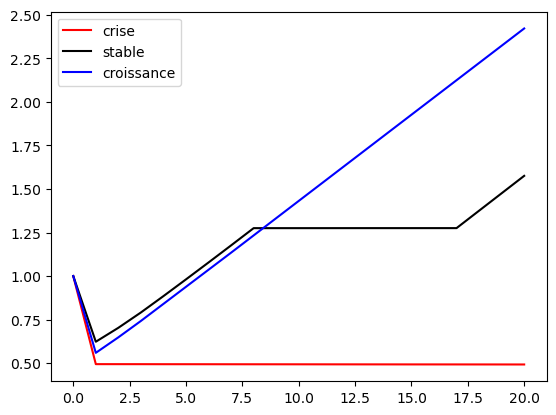

In [13]:
grapheindice= np.arange(0, len(etat0[3]), 1)
plt.plot(grapheindice, etat0[3], color = 'red', label = "crise")
plt.plot(grapheindice, etat1[3], c ='black', label = "stable")
plt.plot(grapheindice, etat2[3], c ='blue', label = "croissance")
plt.legend()
#le graphique comportant l'écolution des titres, en bleu lors l'économie croit, en rouge on se situe récession et en noir on le marché est stable

In [14]:
indice0 = 1
population = 100
titres2 = 10
res = [indice0]
matrice1 = [[1/3, 1/3 ,1/3], [1/3, 1/3 ,1/3], [1/3, 1/3 ,1/3]]  #on a choisi que 3 états, on peut en choisir plus. 

vecteurpopulation4 = np.random.normal(0.5, 0.15, population) 
vecteurindices4 = np.array([np.random.uniform() for _ in range(titres2)])

testaleatoire = fonction_cas1(matrice=matrice1, etat= 2, vecteurpopulation = vecteurpopulation4, vecteurindice=vecteurindices4, n=20, epsilon =0.01)


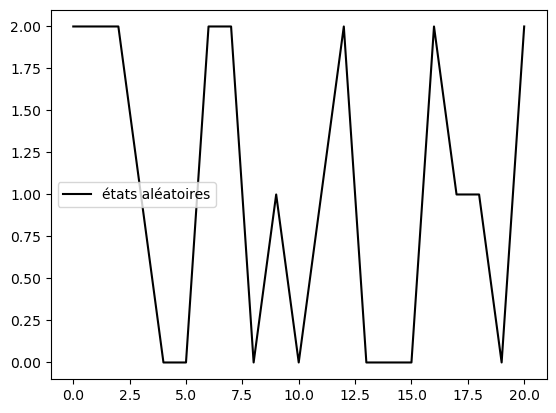

In [15]:
abscisse = np.arange(0, len(testaleatoire[1]), 1)
plt.plot(abscisse, testaleatoire[1], color = 'black', label = "états aléatoires")
plt.legend()

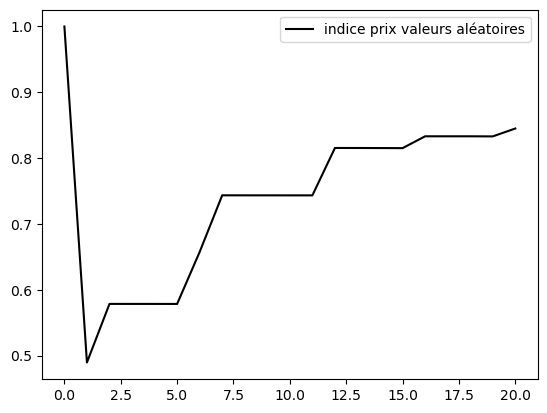

In [16]:
grapheindice= np.arange(0, len(testaleatoire[3]), 1)
plt.plot(grapheindice, testaleatoire[3], color = 'black', label = "indice prix valeurs aléatoires")
plt.legend()   